In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

In [2]:
# Sine wave.
duration = 0.1
samplerate = 16000
times = np.arange(0, duration, 1/samplerate)
freq = 100
waveform = np.sin(2 * np.pi * freq * times)
waveform = np.stack([waveform, waveform])

In [3]:
def add_sto(waveform: np.ndarray, sto_samples: int = 0, channels: list[int] = [1, 3]):
    waveform_sto = np.copy(waveform)
    for c in channels:
        waveform_sto[c] = np.pad(waveform_sto[c, :-sto_samples], (sto_samples, 0))
    return waveform_sto

In [4]:
1/800

0.00125

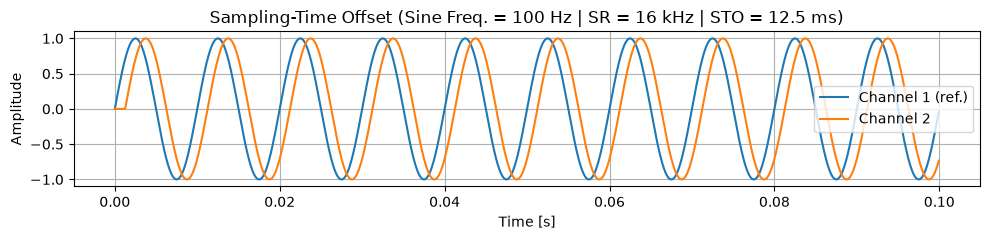

In [5]:
waveform_sto = add_sto(waveform, 20, channels=[1])

fig, axs = plt.subplots(figsize=(10, 2.5))

plt.sca(axs)

plt.plot(times, waveform_sto[0], label="Channel 1 (ref.)")
plt.plot(times, waveform_sto[1], label="Channel 2")

plt.grid()
plt.legend()

plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sampling-Time Offset (Sine Freq. = 100 Hz | SR = 16 kHz | STO = 12.5 ms)")

fig.tight_layout()
plt.savefig(r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\images\sto.png", dpi=300)
plt.show()

In [6]:
def add_sro(waveform: np.ndarray, sro_ppm: float = 0, channels: list[int] = [1, 3]):
    sro_alpha = 1 / (1 + sro_ppm*1e-6)
    samples = np.arange(waveform.shape[1])
    samples_sro = sro_alpha * samples    
    waveform_sro = np.copy(waveform)
    for c in channels:
        waveform_sro[c] = np.interp(x=samples_sro, xp=samples, fp=waveform_sro[c])
    return waveform_sro

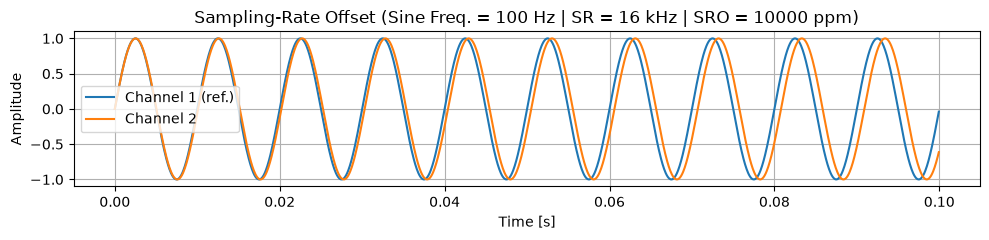

In [7]:
waveform_sro = add_sro(waveform, 10000, channels=[1])

fig, axs = plt.subplots(figsize=(10, 2.5))

plt.sca(axs)

plt.plot(times, waveform_sro[0], label="Channel 1 (ref.)")
plt.plot(times, waveform_sro[1], label="Channel 2")

plt.grid()
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sampling-Rate Offset (Sine Freq. = 100 Hz | SR = 16 kHz | SRO = 10000 ppm)")

fig.tight_layout()
plt.savefig(r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\images\sro.png", dpi=300)
plt.show()

In [8]:
def add_packet_loss_gilbert(waveform: np.ndarray, packet_len: int = 256, packet_loss_rate: float = 0.05, mean_burst_len: int = 512, channels: list[int] = [1, 3]):
    waveform_pl = np.copy(waveform)

    p_bg = packet_len / mean_burst_len
    p_gb = p_bg * packet_loss_rate / (1.0 - packet_loss_rate)
    
    n_state_bad = False
    for n in range(0, waveform.shape[1], packet_len):
        if n_state_bad:
            for c in channels:
                waveform_pl[c, n:n+packet_len] = np.zeros(packet_len) if n+packet_len < waveform.shape[1] else np.zeros(waveform.shape[1]-n)    
            if np.random.rand() < p_bg:
                n_state_bad = False
        else:
            if np.random.rand() < p_gb:
                n_state_bad = True

    return waveform_pl

In [9]:
waveform_pl = add_packet_loss_gilbert(waveform, packet_len=50, packet_loss_rate=0.15, mean_burst_len=100, channels=[1])

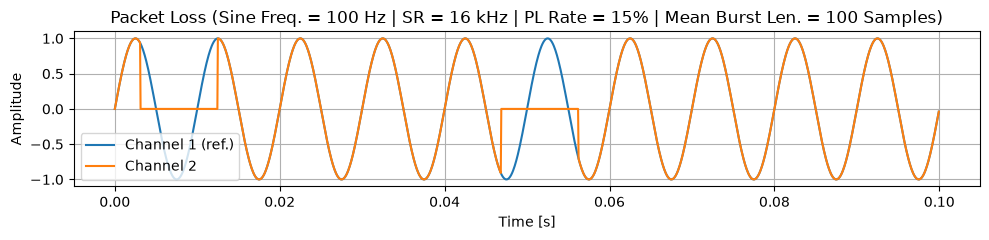

In [10]:

fig, axs = plt.subplots(figsize=(10, 2.5))

plt.sca(axs)

plt.plot(times, waveform_pl[0], label="Channel 1 (ref.)")
plt.plot(times, waveform_pl[1], label="Channel 2",)

plt.grid()
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Packet Loss (Sine Freq. = 100 Hz | SR = 16 kHz | PL Rate = 15% | Mean Burst Len. = 100 Samples)")

fig.tight_layout()
plt.savefig(r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\images\pl.png", dpi=300)
plt.show()

In [12]:
file_path_src = r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\audio\69.wav"

x, sr = sf.read(file_path_src)
x = x.mT

file_path_dst = r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\audio\69_stereo.mp3"
sf.write(file_path_dst, x[:2].mT, sr)

In [13]:
x_sto = add_sto(x, sto_samples=40)
x_sro = add_sro(x, sro_ppm=60)
x_pl = add_packet_loss_gilbert(x, packet_len=256, packet_loss_rate=0.1, mean_burst_len=512)

file_path_sto = r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\audio\69_sto.mp3"
file_path_sro = r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\audio\69_sro.mp3"
file_path_pl = r"C:\Users\toviste\Local_Documents\code\ovistetom.github.io\wasn_imperfections\audio\69_pl.mp3"

sf.write(file_path_sto, x_sto[:2].mT, sr)
sf.write(file_path_sro, x_sro[:2].mT, sr)
sf.write(file_path_pl, x_pl[:2].mT, sr)